# Probability density matrix 

 In this notebook we show how to call the probability densitity matrix for arbitrary NSI

First import the model class

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from snudd.models import GeneralNSI

We will start with the Standard Model (SM), i.e. all NSI parameters are set to zero.

In [2]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

eta = 0
phi = 0

sm_model = GeneralNSI(SM_matrix, eta, phi)

We import the probabilities module

In [3]:
import snudd.nsi.nsi_probabilities as probs

Declare neutrino energy array 

In [4]:
enus = np.geomspace(1e-6,1e0,200)

## Neutrino survival and dissapearance probabilities

For example, to call the $\nu_{e}$ survival probabilities 

In [5]:
probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B') # Survival

array([0.54209555, 0.5420936 , 0.54209152, 0.54208928, 0.54208688,
       0.54208431, 0.54208156, 0.5420786 , 0.54207544, 0.54207205,
       0.54206841, 0.54206451, 0.54206033, 0.54205585, 0.54205105,
       0.5420459 , 0.54204039, 0.54203447, 0.54202813, 0.54202134,
       0.54201405, 0.54200624, 0.54199787, 0.5419889 , 0.54197928,
       0.54196897, 0.54195792, 0.54194607, 0.54193337, 0.54191975,
       0.54190515, 0.54188951, 0.54187273, 0.54185475, 0.54183547,
       0.5418148 , 0.54179265, 0.54176889, 0.54174343, 0.54171613,
       0.54168686, 0.54165548, 0.54162183, 0.54158576, 0.54154708,
       0.54150561, 0.54146115, 0.54141347, 0.54136235, 0.54130753,
       0.54124874, 0.54118571, 0.5411181 , 0.54104561, 0.54096785,
       0.54088447, 0.54079503, 0.54069909, 0.54059619, 0.54048581,
       0.54036739, 0.54024036, 0.54010406, 0.53995782, 0.5398009 ,
       0.53963251, 0.53945179, 0.53925783, 0.53904964, 0.53882615,
       0.53858621, 0.53832859, 0.53805195, 0.53775485, 0.53743

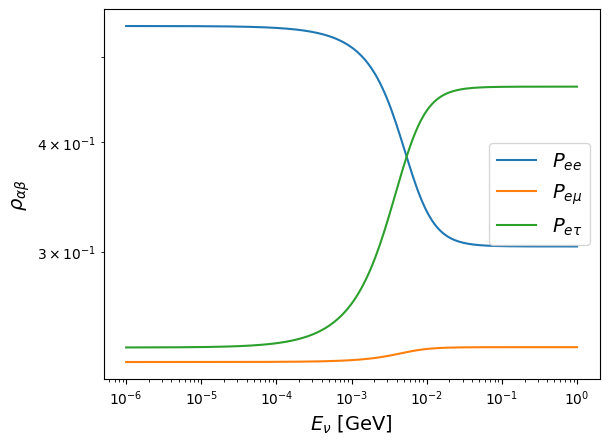

In [6]:
plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'), label=r'$P_{ee}$')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'), label=r'$P_{e\mu}$')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'), label=r'$P_{e\tau}$' )



plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

plt.legend(fontsize=14)


## Neutrino density matrix $\rho$

Now we use the more general probability density matrix as in equation (1) of our [paper](https://inspirehep.net/literature/2636793)

$$\frac{\rm{d}R}{\rm{d}E_R}=  N_T \int_{E_\nu^\mathrm{min}} \frac{\rm{d}\phi_\nu}{\rm{d}E_\nu}\,  \mathrm{Tr}\left[ \rho\, \frac{\rm{d}\zeta}{ \rm{d}E_R}\right] \, \rm{d} E_\nu\, .$$

We can call this matrix in a similar way to before 

In [7]:
density_sm = probs.DensityMatrixCalculator(sm_model).density(enus, '8B')

The output is an array of $n\times3\times3$ matrix, where $n$ is the length of $E_\nu$  

In [8]:
np.shape(density_sm)

(200, 3, 3)

For comparison we can plot the diagonal denisty matrix elements against the survival and disappearance probabilities from before.

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

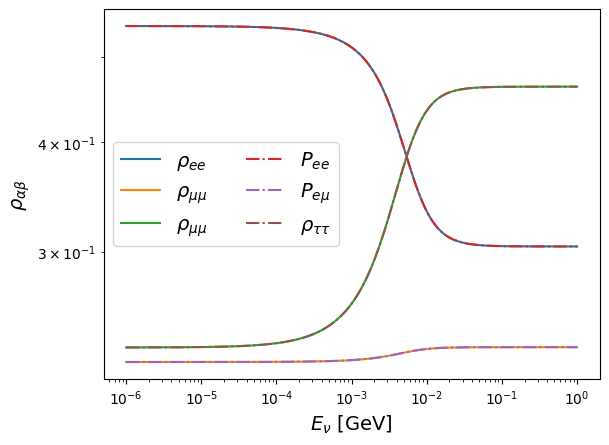

In [9]:
plt.loglog(enus,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

plt.loglog(enus,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')


plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-.' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

For completness, let us plot all six independent density matrix elements.

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

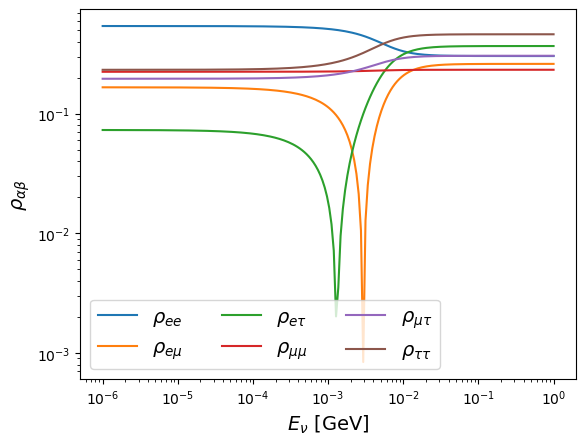

In [10]:
plt.loglog(enus,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus,abs(density_sm[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(enus,abs(density_sm[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(enus,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(enus,abs(density_sm[:, 1,2]),  label=r'$\rho_{\mu\tau}$')
plt.loglog(enus,abs(density_sm[:, 2,2]),  label=r'$\rho_{\tau\tau}$')


plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## Adding NSI

Now we can calculate the density matrix with nonzero NSI parameters. For example with $\varepsilon_{\mu\tau}=0.1$ with equal couplings to protons and neutrons ($\eta=\pi/4$).

In [11]:
NSI_matrix = np.array([[0.0, 0.0, 0.0],
                       [0.0, 0.0, 0.1],
                       [0.0, 0.1, 0.0]])

eta = np.pi/4
phi = 0

NSI_model = GeneralNSI(NSI_matrix, eta, phi)

In [12]:
density_NSI = probs.DensityMatrixCalculator(NSI_model).density(enus, '8B')

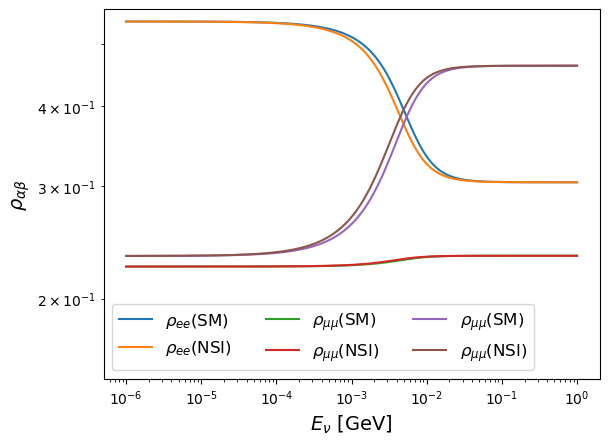

In [13]:
plt.plot(enus,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee} ({\rm SM})$')
plt.loglog(enus,abs(density_NSI[:, 0,0]),  label=r'$\rho_{ee}({\rm NSI})$')

plt.loglog(enus,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}({\rm SM})$')
plt.loglog(enus,abs(density_NSI[:, 1,1]),  label=r'$\rho_{\mu\mu}({\rm NSI})$')


plt.loglog(enus,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}({\rm SM})$')



plt.loglog(enus,abs(density_NSI[:, 2,2]),  label=r'$\rho_{\mu\mu}({\rm NSI})$')


plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

plt.ylim(ymin=1.5e-1)
plt.legend(fontsize=12, ncol=3)

#### Altering the oscillation parameters 

In [14]:
from snudd.nsi.oscillation import OscillationParameters

In [21]:
np.cos(np.pi)

-1.0

In [ ]:
# OSC VALS FROM 2006.11237
delta_m12 = 7.50e-5 * (1e-9) ** 2  # GeV^2
theta_12 = 34.3 * np.pi / 180
theta_13 = 8.58 * np.pi / 180  # NORMAL ORDERING
theta_23 = 49.26 * np.pi / 180
#delta_cp = np.pi  # CP angle

In [31]:
params_cp_pi = OscillationParameters(delta_m12,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        np.pi)

In [33]:
params_cp_pi_2 = OscillationParameters(delta_m12,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        np.pi/2)

In [ ]:
probs.ProbabilityCalculator(sm_model, osc_params=params_cp).prob_ee_3nu(enus, '8B') # Survival

In [28]:
Pnewcp

array([0.54209555, 0.5420936 , 0.54209152, 0.54208928, 0.54208688,
       0.54208431, 0.54208156, 0.5420786 , 0.54207544, 0.54207205,
       0.54206841, 0.54206451, 0.54206033, 0.54205585, 0.54205105,
       0.5420459 , 0.54204039, 0.54203447, 0.54202813, 0.54202134,
       0.54201405, 0.54200624, 0.54199787, 0.5419889 , 0.54197928,
       0.54196897, 0.54195792, 0.54194607, 0.54193337, 0.54191975,
       0.54190515, 0.54188951, 0.54187273, 0.54185475, 0.54183547,
       0.5418148 , 0.54179265, 0.54176889, 0.54174343, 0.54171613,
       0.54168686, 0.54165548, 0.54162183, 0.54158576, 0.54154708,
       0.54150561, 0.54146115, 0.54141347, 0.54136235, 0.54130753,
       0.54124874, 0.54118571, 0.5411181 , 0.54104561, 0.54096785,
       0.54088447, 0.54079503, 0.54069909, 0.54059619, 0.54048581,
       0.54036739, 0.54024036, 0.54010406, 0.53995782, 0.5398009 ,
       0.53963251, 0.53945179, 0.53925783, 0.53904964, 0.53882615,
       0.53858621, 0.53832859, 0.53805195, 0.53775485, 0.53743

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

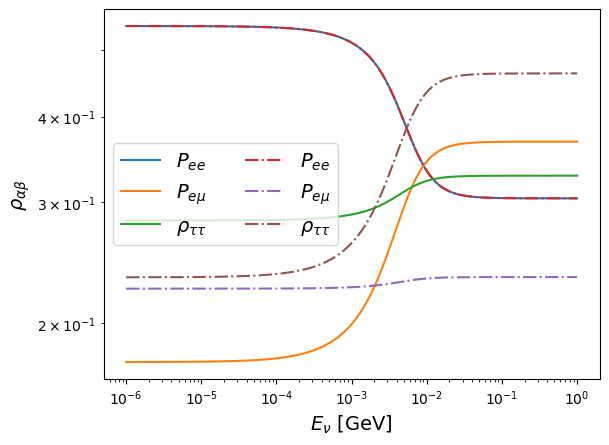

In [35]:


plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-' )

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-.' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

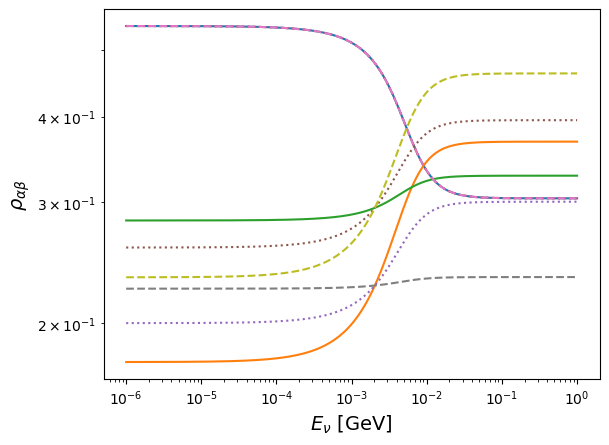

In [ ]:

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-' )

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls=':')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls=':')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls=':' )

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='--')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='--')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='--' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
#plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

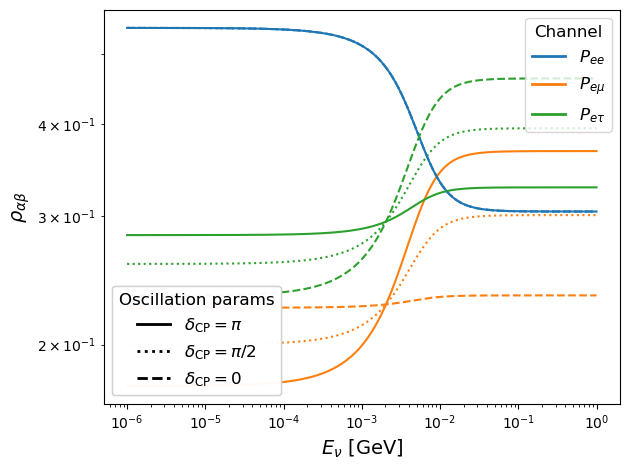

In [37]:
from matplotlib.lines import Line2D

# --- choose three consistent colors from the current matplotlib cycle ---
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {
    'ee':   cycle_colors[0],
    'emu':  cycle_colors[1],
    'etau': cycle_colors[2],
}

# --- define linestyles and labels for the three osc. parameter sets ---
# Adjust these δ_CP labels to match your actual params if needed.
ls_label_map = {
    'pi':   {'ls': '-',  'label': r'$\delta_{\rm CP}=\pi$'},
    'pi2':  {'ls': ':',  'label': r'$\delta_{\rm CP}=\pi/2$'},
    'zero': {'ls': '--', 'label': r'$\delta_{\rm CP}=0$'},
}

# Build calculators once (avoids repeated instantiation)
calc_pi   = probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi)
calc_pi2  = probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2)
calc_zero = probs.ProbabilityCalculator(sm_model)  # default osc params

# --- plot: each channel has a fixed color; each param-set uses a different linestyle ---
# δ_CP = π
plt.loglog(enus, calc_pi.prob_ee_3nu(enus, '8B'),   ls=ls_label_map['pi']['ls'],   color=color_map['ee'])
plt.loglog(enus, calc_pi.prob_emu_3nu(enus, '8B'),  ls=ls_label_map['pi']['ls'],   color=color_map['emu'])
plt.loglog(enus, calc_pi.prob_etau_3nu(enus, '8B'), ls=ls_label_map['pi']['ls'],   color=color_map['etau'])

# δ_CP = π/2
plt.loglog(enus, calc_pi2.prob_ee_3nu(enus, '8B'),   ls=ls_label_map['pi2']['ls'],  color=color_map['ee'])
plt.loglog(enus, calc_pi2.prob_emu_3nu(enus, '8B'),  ls=ls_label_map['pi2']['ls'],  color=color_map['emu'])
plt.loglog(enus, calc_pi2.prob_etau_3nu(enus, '8B'), ls=ls_label_map['pi2']['ls'],  color=color_map['etau'])

# δ_CP = 0
plt.loglog(enus, calc_zero.prob_ee_3nu(enus, '8B'),   ls=ls_label_map['zero']['ls'], color=color_map['ee'])
plt.loglog(enus, calc_zero.prob_emu_3nu(enus, '8B'),  ls=ls_label_map['zero']['ls'], color=color_map['emu'])
plt.loglog(enus, calc_zero.prob_etau_3nu(enus, '8B'), ls=ls_label_map['zero']['ls'], color=color_map['etau'])

# --- labels & axes ---
plt.xlabel(r'$E_{\nu}\,\,[\mathrm{GeV}]$', fontsize=14)
plt.ylabel(r'$\rho_{\alpha\beta}$', fontsize=14)

# --- bespoke legends ---
# 1) Color legend: one entry per channel (shows colors only)
color_handles = [
    Line2D([0],[0], lw=2, color=color_map['ee'],   ls='-', label=r'$P_{ee}$'),
    Line2D([0],[0], lw=2, color=color_map['emu'],  ls='-', label=r'$P_{e\mu}$'),
    Line2D([0],[0], lw=2, color=color_map['etau'], ls='-', label=r'$P_{e\tau}$'),
]
leg1 = plt.legend(handles=color_handles, title="Channel", fontsize=12, title_fontsize=12, loc='upper right')

# 2) Linestyle legend: one entry per δ_CP (shows linestyles only)
ls_handles = [
    Line2D([0],[0], lw=2, color='black', ls=ls_label_map['pi']['ls'],   label=ls_label_map['pi']['label']),
    Line2D([0],[0], lw=2, color='black', ls=ls_label_map['pi2']['ls'],  label=ls_label_map['pi2']['label']),
    Line2D([0],[0], lw=2, color='black', ls=ls_label_map['zero']['ls'], label=ls_label_map['zero']['label']),
]
leg2 = plt.legend(handles=ls_handles, title=r'Oscillation params', fontsize=12, title_fontsize=12, loc='lower left')

# Make both legends show
ax = plt.gca()
ax.add_artist(leg1)
ax.add_artist(leg2)

plt.tight_layout()
# plt.savefig('solar_probs.pdf', bbox_inches='tight')
plt.show()


In [40]:
density_sm_cppi = probs.DensityMatrixCalculator(sm_model, osc_params=params_cp_pi).density(enus, '8B')

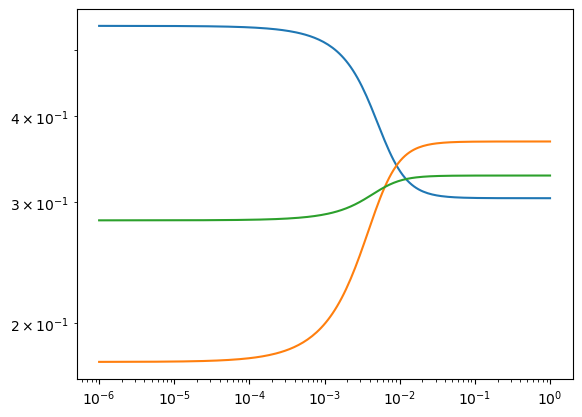

In [45]:
plt.loglog(enus,abs(density_sm_cppi[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus,abs(density_sm_cppi[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

plt.loglog(enus,abs(density_sm_cppi[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

Text(0.5, 1.0, '$\\delta_{\\rm cp}=\\pi$')

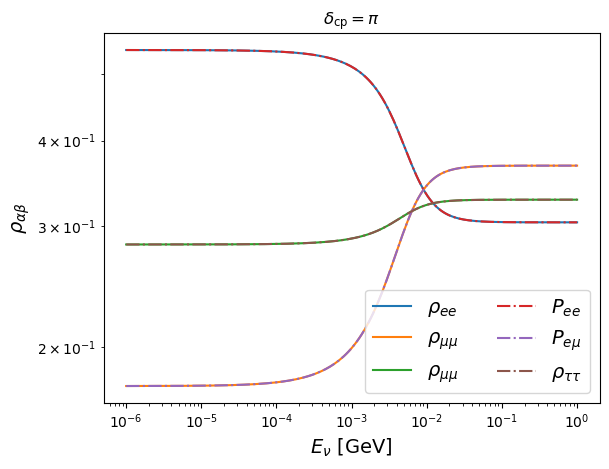

In [49]:
plt.loglog(enus,abs(density_sm_cppi[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus,abs(density_sm_cppi[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

plt.loglog(enus,abs(density_sm_cppi[:, 2,2]),  label=r'$\rho_{\mu\mu}$')


plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model,osc_params=params_cp_pi).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model,osc_params=params_cp_pi).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model,osc_params=params_cp_pi).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-.' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

plt.title(r"$\delta_{\rm cp}=\pi$")